# Load the CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH = Path("summary.csv")         
df = pd.read_csv(CSV_PATH)

print(f"⦿ rows: {len(df):,}")
df.head()

⦿ rows: 834


,tile_id,timestamp,ice_px,water_px,cloud_px,land_px,nodata_px,unknown_px,ice_pct,water_pct,cloud_pct,land_pct,nodata_pct,mean_ndsi_ice,mean_ndwi_water,eo_cloud_cover,sun_elev,sun_azim,edge_gap
0,S2B_22WDD_20210420_0_L1C,20210420T155255,151652,5,0,15008,0,39,0.9097,0.0000,0.0000,0.09,0.0000,0.9129,0.0893,18.133700,NaN,NaN,0.0
1,S2C_22WDD_20250421_0_L1C,20250421T154325,135069,14892,1561,15008,0,174,0.8102,0.0893,0.0094,0.09,0.0000,0.5574,0.1408,0.000000,NaN,NaN,0.0
2,S2B_22WDD_20250420_0_L1C,20250420T152309,140457,9220,0,15008,6989,-4970,0.8426,0.0553,0.0000,0.09,0.0419,0.5619,0.1564,2.774324,NaN,NaN,0.0
3,S2B_22WDD_20250419_0_L1C,20250419T155303,134245,16264,50,15008,0,1137,0.8053,0.0976,0.0003,0.09,0.0000,0.5122,0.1027,41.707404,NaN,NaN,0.0
4,S2C_22WDD_20250418_0_L1C,20250418T153327,136576,14634,0,15008,0,486,0.8193,0.0878,0.0000,0.09,0.0000,0.5325,0.1054,50.402610,NaN,NaN,0.0


# Basic Cleaning

In [2]:
# Timestamp → real datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y%m%dT%H%M%S")

# Only keep sensible, non-negative pixel counts
pix_cols = ["ice_px","water_px","cloud_px","land_px","nodata_px","unknown_px"]
for col in pix_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df.loc[df[col] < 0, col] = np.nan      # drop nagative artefacts

# Ensure fraction columns are floats
frac_cols = ["ice_pct","water_pct","cloud_pct","land_pct","nodata_pct"]
df[frac_cols] = df[frac_cols].apply(pd.to_numeric, errors="coerce")

# Set timestamp as index for time-series convenience
df = df.sort_values("timestamp").set_index("timestamp")

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 834 entries, 2021-02-10 15:23:06 to 2025-04-21 15:43:25
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tile_id          834 non-null    object 
 1   ice_px           834 non-null    float64
 2   water_px         834 non-null    float64
 3   cloud_px         834 non-null    float64
 4   land_px          834 non-null    float64
 5   nodata_px        834 non-null    float64
 6   unknown_px       470 non-null    float64
 7   ice_pct          834 non-null    float64
 8   water_pct        834 non-null    float64
 9   cloud_pct        834 non-null    float64
 10  land_pct         834 non-null    float64
 11  nodata_pct       834 non-null    float64
 12  mean_ndsi_ice    700 non-null    float64
 13  mean_ndwi_water  646 non-null    float64
 14  eo_cloud_cover   834 non-null    float64
 15  sun_elev         0 non-null      float64
 16  sun_azim         1 non-nu

# Data Quality Check

In [3]:
missing = df.isna().mean().sort_values(ascending=False) * 100
print("Fraction of NaNs per column (%):\n", missing.round(1))


Fraction of NaNs per column (%):
 sun_elev           100.0
sun_azim            99.9
unknown_px          43.6
mean_ndwi_water     22.5
mean_ndsi_ice       16.1
edge_gap             0.1
land_pct             0.0
eo_cloud_cover       0.0
nodata_pct           0.0
tile_id              0.0
ice_px               0.0
water_pct            0.0
ice_pct              0.0
nodata_px            0.0
land_px              0.0
cloud_px             0.0
water_px             0.0
cloud_pct            0.0
dtype: float64


# Daily / running means of ice & water fractions

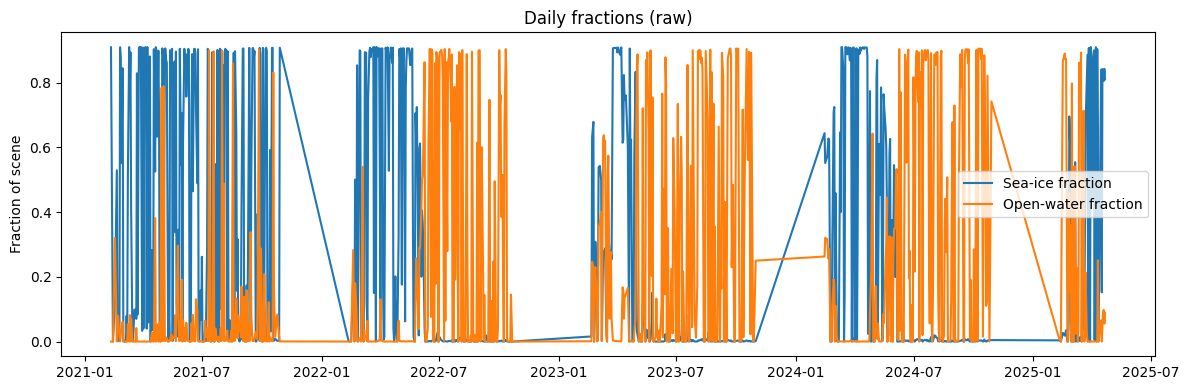

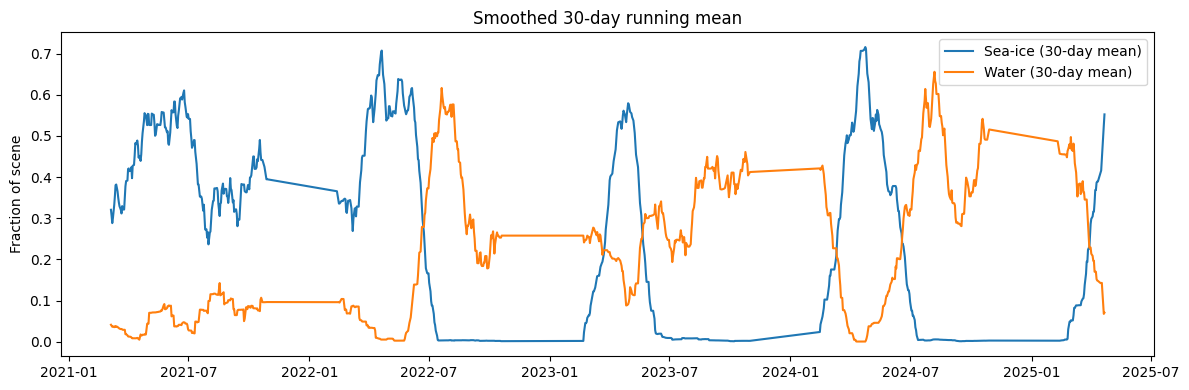

In [4]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["ice_pct"], label="Sea-ice fraction")
plt.plot(df.index, df["water_pct"], label="Open-water fraction")
plt.ylabel("Fraction of scene")
plt.title("Daily fractions (raw)")
plt.legend()
plt.tight_layout()
plt.show()

# 30-day running mean to smooth weather/cloud noise
s = df[["ice_pct","water_pct"]].rolling(30, min_periods=15).mean()

plt.figure(figsize=(12,4))
plt.plot(s.index, s["ice_pct"], label="Sea-ice (30-day mean)")
plt.plot(s.index, s["water_pct"], label="Water (30-day mean)")
plt.ylabel("Fraction of scene")
plt.title("Smoothed 30-day running mean")
plt.legend()
plt.tight_layout()
plt.show()


# Seasonal Cycle


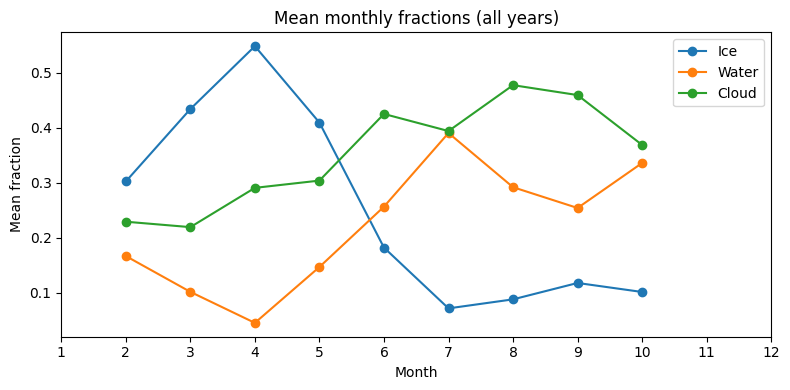

In [5]:
mon = df.groupby(df.index.month)[["ice_pct","water_pct","cloud_pct"]].mean()

plt.figure(figsize=(8,4))
plt.plot(mon.index, mon["ice_pct"], marker="o", label="Ice")
plt.plot(mon.index, mon["water_pct"], marker="o", label="Water")
plt.plot(mon.index, mon["cloud_pct"], marker="o", label="Cloud")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Mean fraction")
plt.title("Mean monthly fractions (all years)")
plt.legend()
plt.tight_layout()
plt.show()


# 365 Days Rolling Trend (Multi-Average)

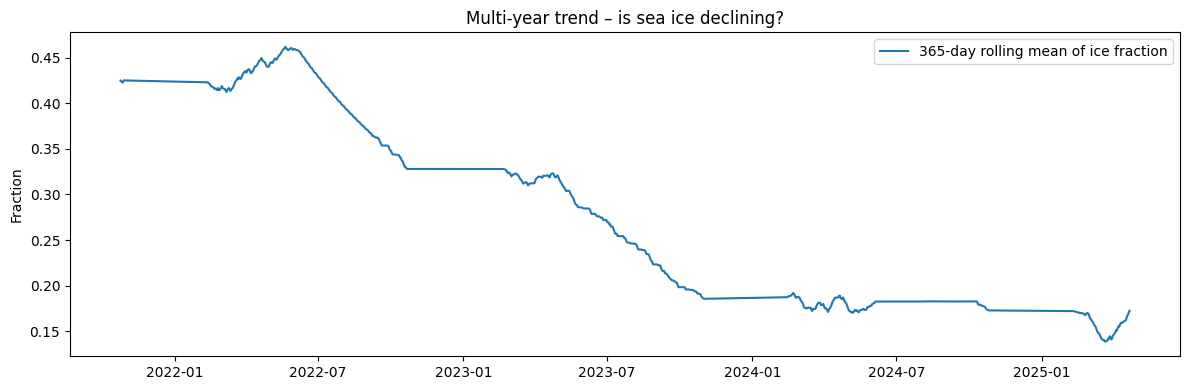

In [6]:
trend = df["ice_pct"].rolling(365, min_periods=200).mean()

plt.figure(figsize=(12,4))
plt.plot(trend.index, trend, label="365-day rolling mean of ice fraction")
plt.ylabel("Fraction")
plt.title("Multi-year trend – is sea ice declining?")
plt.legend()
plt.tight_layout()
plt.show()


## Sun-elevation & cloud-cover effects

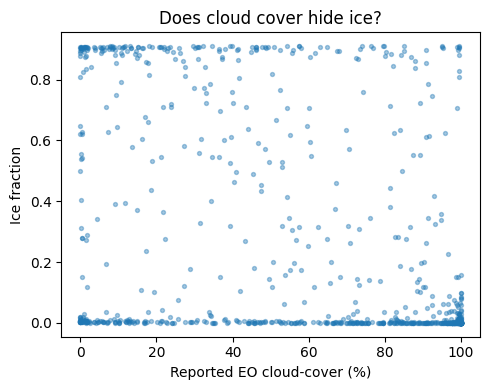

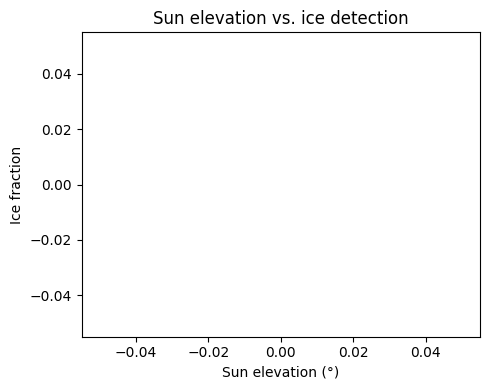

In [7]:
# Simple scatter: cloud cover vs. ice_pct
plt.figure(figsize=(5,4))
plt.scatter(df["eo_cloud_cover"], df["ice_pct"], s=8, alpha=0.4)
plt.xlabel("Reported EO cloud-cover (%)")
plt.ylabel("Ice fraction")
plt.title("Does cloud cover hide ice?")
plt.tight_layout()
plt.show()

# Scatter: sun elevation vs. ice_pct (low sun ⇒ hard radiometry?)
plt.figure(figsize=(5,4))
plt.scatter(df["sun_elev"], df["ice_pct"], s=8, alpha=0.4)
plt.xlabel("Sun elevation (°)")
plt.ylabel("Ice fraction")
plt.title("Sun elevation vs. ice detection")
plt.tight_layout()
plt.show()


## Correlation matrix for all numeric variables

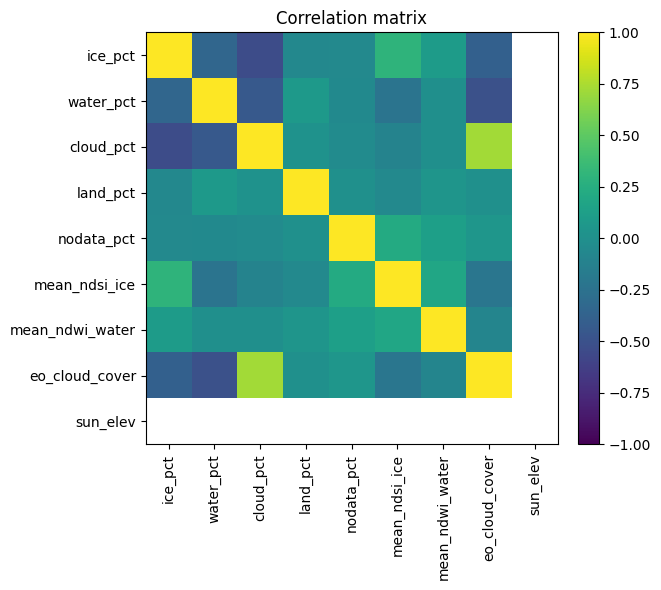

In [8]:
num_cols = frac_cols + ["mean_ndsi_ice","mean_ndwi_water","eo_cloud_cover","sun_elev"]
corr = df[num_cols].corr()

plt.figure(figsize=(7,6))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


##  Save cleaned dataframe for future work

In [9]:
CLEAN_CSV = Path("summary_clean.csv")
df.to_csv(CLEAN_CSV)
print("✓ Saved cleaned file:", CLEAN_CSV.resolve())


✓ Saved cleaned file: /Users/lukaskreibig/Documents/Dokumente Cloud/climate-dashboard/uummannaq-ice/ice-final/summary_clean.csv


## Sen/Theil–Sen trend analysis

ice_pct: slope ≈ -0.001 / yr  (95 % CI -0.322 … +0.148)
water_pct: slope ≈ +0.003 / yr  (95 % CI -0.065 … +0.133)


/var/folders/2l/6514_hd91tv5448lmq79vpbw0000gn/T/ipykernel_9279/76665688.py:5: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = df[["ice_pct", "water_pct"]].resample("A").median()


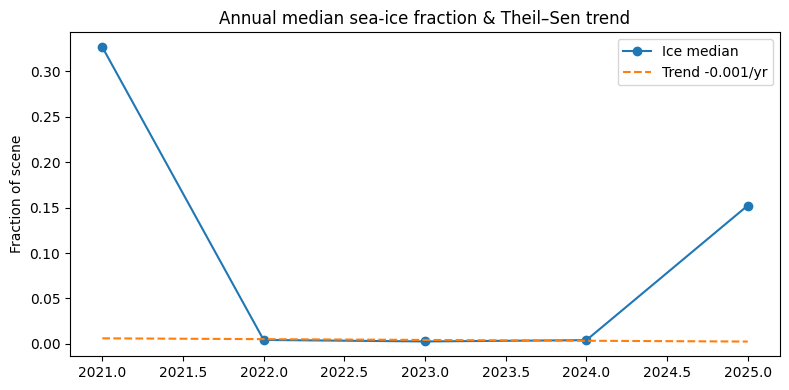

In [10]:
# %%  ── A1. Sen / Theil–Sen slope on annual medians ────────────────
from scipy.stats import theilslopes

# resample to annual median ice+water fractions to damp out seasonality
annual = df[["ice_pct", "water_pct"]].resample("A").median()

# compute Theil–Sen slope (fraction change per year)
for var in ["ice_pct", "water_pct"]:
    y = annual[var].dropna().values
    x = np.arange(len(y))        # 0,1,2… years
    slope, intercept, lo, hi = theilslopes(y, x, 0.95)
    print(f"{var}: slope ≈ {slope:+.3f} / yr  (95 % CI {lo:+.3f} … {hi:+.3f})")

# quick plot
plt.figure(figsize=(8,4))
plt.plot(annual.index.year, annual["ice_pct"], 'o-', label="Ice median")
m, b = theilslopes(annual["ice_pct"], annual.index.year, 0.95)[:2]
plt.plot(annual.index.year, m*annual.index.year + b, '--', label=f"Trend {m:+.3f}/yr")
plt.ylabel("Fraction of scene")
plt.title("Annual median sea-ice fraction & Theil–Sen trend")
plt.legend(); plt.tight_layout(); plt.show()
